In [1]:
from pydantic import BaseModel, Field
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from operator import add
from typing import Any, Annotated, Dict, List

from langchain_core.messages import BaseMessage, AIMessage, ToolMessage, HumanMessage, SystemMessage
from langchain_core.tools import BaseTool
from langchain_core.prompts import BasePromptTemplate
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.prompts import StringPromptTemplate
from langchain_core.prompts import PromptTemplate
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import convert_to_openai_messages, convert_to_messages
from langchain_protocol import Literal

from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PayloadSchemaType, PointStruct, SparseVectorParams, Document,Prefetch, FusionQuery
from qdrant_client import models

import instructor
from langsmith import traceable, get_current_run_tree

import pandas as pd
import openai
import fastembed

from jinja2 import Template
from typing import List, Dict, Any, Optional, Union
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json
import os
import importlib
import utils
from dotenv import load_dotenv

load_dotenv()
importlib.reload(utils)

from utils import format_ai_message, parse_function_definition, get_type_from_annotation, parse_docstring_params, get_tool_descriptions

/Users/kishorkumarparoi/Desktop/Maven - The AI Engineering Bootcamp /Resources/AIE5-main/24_Langgraph/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

# Retrieve API keys from environment variables
openai_api_key = os.getenv('OPENAI_API_KEY')
google_api_key = os.getenv('GEMINI_API_KEY')
qdrant_url = os.getenv('QDRANT_URL')
qdrant_api_key = os.getenv('QDRANT_API_KEY')
langsmith_api_key = os.getenv('LANGSMITH_API_KEY')
if qdrant_url and "qdrant:6333" in qdrant_url:
    # Docker service host is not resolvable from a local notebook kernel
    qdrant_url = qdrant_url.replace("qdrant:6333", "localhost:6333")

# Verify keys are loaded
print(f"OpenAI API Key present: {bool(openai_api_key)}")
print(f"Google API Key present: {bool(google_api_key)}")
print(f"Qdrant URL present: {bool(qdrant_url)}")
print(f"Qdrant API Key present: {bool(qdrant_api_key)}")
print(f"Langsmith API Key present: {bool(langsmith_api_key)}")

qdrant_client = QdrantClient(
    url=qdrant_url,
    api_key=qdrant_api_key,
)

OpenAI API Key present: True
Google API Key present: False
Qdrant URL present: True
Qdrant API Key present: False
Langsmith API Key present: True


/var/folders/pw/cff5mdz55nb7ghs1f4rh8f9r0000gn/T/ipykernel_5346/4105341488.py:20: UserWarning: Api key is used with an insecure connection.
  qdrant_client = QdrantClient(


In [3]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )
    return response.data[0].embedding

In [4]:
def retrieve_data(query, qdrant_client, top_k=5):
    query_embedding = get_embedding(query)
    search_result = qdrant_client.query_points(
        collection_name="Amazon_Electronics_Products",
        prefetch = [
            Prefetch(
            query = query_embedding,
            using= "text-embedding-3-small",
            limit = 20
           ),
           Prefetch(
            query = Document(text=query, model="qdrant/bm25"),
            using= "bm25",
            limit = 20
           )
        ],
        query=FusionQuery(fusion=models.Fusion.RRF),
        limit=top_k
    )

    retrieved_context_ids = []
    retrieved_contexts = []
    similarity_scores = []
    retrieved_context_ratings = []
    retrieved_context_prices = []
    retrieved_context_images = []
    retrieved_context_rating_numbers = []

    for result in search_result.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_contexts.append(result.payload['processed_description'])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload['average_rating'])
        retrieved_context_prices.append(result.payload['price'])
        retrieved_context_images.append(result.payload['image_url'])
        retrieved_context_rating_numbers.append(result.payload['rating_number'])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_contexts": retrieved_contexts,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings,
        "retrieved_context_prices": retrieved_context_prices,
        "retrieved_context_images": retrieved_context_images,
        "retrieved_context_rating_numbers": retrieved_context_rating_numbers
    }

In [5]:
query = "Can I get a Tablet?"

In [6]:
answer = retrieve_data(query, qdrant_client, top_k=5)

In [7]:
answer

{'retrieved_context_ids': ['B09S6THZJ1',
  'B07K89WHJH',
  'B07GXM524L',
  'B08DXTHKQ7',
  'B089CW1PC7'],
 'retrieved_contexts': ["GrandPad Tablet for Seniors, Accessibility Enabled Tablet, 4G LTE, Bluetooth Enabled Tablet with Wireless Charger, Stylus - 1 Month Premium Service with 4G Included [] Computers ['MADE FOR SENIOR CITIZENS: The GrandPad is the ideal connectivity device for your loved ones who are aging, or have hearing & eyesight issues. A simple interface & easy-connectivity makes it the perfect choice for families looking to stay connected.', 'KEEPING FAMILIES CONNECTED: The tablet comes with a custom-designed senior friendly interface, applications, unlimited 24/7/365 customer support, free companion applications for Android and iOS (for other family members), a private network to share & connect with your loved ones. Designed to be used by people above 75 years of age with ease.', '4G LTE CONNECTED TABLET: This tablet is ideal for connecting to your aging loved ones, sin

## Multi Intent Questions

In [8]:
query = "Can I get a Tablet for my kid, a watch for me and a laptop for my wife?"

In [9]:
answer = retrieve_data(query, qdrant_client, top_k=5)

In [10]:
answer

{'retrieved_context_ids': ['B09S6THZJ1',
  'B0BCG4YDFJ',
  'B078GFVGQZ',
  'B08CS9L1NS',
  'B07C3G57MG'],
 'retrieved_contexts': ["GrandPad Tablet for Seniors, Accessibility Enabled Tablet, 4G LTE, Bluetooth Enabled Tablet with Wireless Charger, Stylus - 1 Month Premium Service with 4G Included [] Computers ['MADE FOR SENIOR CITIZENS: The GrandPad is the ideal connectivity device for your loved ones who are aging, or have hearing & eyesight issues. A simple interface & easy-connectivity makes it the perfect choice for families looking to stay connected.', 'KEEPING FAMILIES CONNECTED: The tablet comes with a custom-designed senior friendly interface, applications, unlimited 24/7/365 customer support, free companion applications for Android and iOS (for other family members), a private network to share & connect with your loved ones. Designed to be used by people above 75 years of age with ease.', '4G LTE CONNECTED TABLET: This tablet is ideal for connecting to your aging loved ones, sin

In [11]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [12]:
def query_expand_node(query) -> list[str]:
    import re

    prompt_template = f"""You are an expert query expansion assistant for shopping search.
    Break the user's request into multiple non-overlapping search statements.

    Rules:
    - Identify every product mentioned in the query.
    - If multiple products are mentioned, create separate statements for each product.
    - Include family-member intent when present, such as "for me", "for my kid", or "for my family".
    - Expand the query into statements that can help retrieve product information, such as category, features, use case, budget, and brand.
    - Keep the statements specific, product-focused, and non-redundant.
    - Preserve the exact product names when they are explicitly provided.
    - Do not replace the mentioned products with unrelated products.
    - Return only the list of statements.

    Explicit products mentioned in the query:
    {{explicit_products}}

    <Question>
    {{query}}
    </Question>
    """
    
    template = Template(prompt_template)
    explicit_products = re.findall(r'"([^"]+)"', query)
    prompt = template.render(
        query=query,
        explicit_products=", ".join(explicit_products) if explicit_products else "None",
    )

    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role":"system", "content": prompt}],
        temperature=0.1,
    )

    if isinstance(response, (tuple, list)):
        response = response[0]

    if hasattr(response, "model_dump"):
        response_data = response.model_dump()
    elif hasattr(response, "dict"):
        response_data = response.dict()
    else:
        response_data = dict(response)

    statements = response_data.get("statements") or response_data.get("queries") or response_data.get("expanded_query") or []

    if explicit_products:
        filtered_statements = [
            statement for statement in statements
            if any(product.lower() in statement.lower() for product in explicit_products)
        ]
        if filtered_statements:
            return filtered_statements

        return [
            f"Search for {product} options for the specified user or family member"
            for product in explicit_products
        ]

    return statements

In [13]:
query = "expand this query: can I get \"Laptop\", \"Watch\" and \"Iphone\" for me and my family?"

In [14]:
expanded_queries = query_expand_node(query)

In [15]:
expanded_queries

['Search for Laptop options for the specified user or family member',
 'Search for Watch options for the specified user or family member',
 'Search for Iphone options for the specified user or family member']

In [16]:
print(expanded_queries)

['Search for Laptop options for the specified user or family member', 'Search for Watch options for the specified user or family member', 'Search for Iphone options for the specified user or family member']


### LangGraph 
Query Expansion (Sequential Execution)

In [62]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[dict], add] = []
    initial_query: str = ""
    answer: str = ""
    question_relevant: bool = False


Query Expansion/Rewriting Node

In [18]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [79]:
@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expand_node(state: State) -> dict:
    import re

    if not getattr(state, "question_relevant", False):
        return {"expanded_query": []}

    prompt_template = f"""You are an expert query expansion assistant for shopping search.
    Break the user's request into multiple non-overlapping search statements.

    Rules:
    - Identify every product mentioned in the query.
    - If multiple products are mentioned, create separate statements for each product.
    - Include family-member intent when present, such as "for me", "for my kid", or "for my family".
    - Expand the query into statements that can help retrieve product information, such as category, features, use case, budget, and brand.
    - Keep the statements specific, product-focused, and non-redundant.
    - Preserve the exact product names when they are explicitly provided.
    - Do not replace the mentioned products with unrelated products.
    - Return only the list of statements.

    Explicit products mentioned in the query:
    {{explicit_products}}

    <Question>
    {{query}}
    </Question>
    """

    def _extract_products(text: str) -> list[str]:
        quoted = re.findall(r'"([^"]+)"', text)
        phrase_matches = re.findall(r"\b(?:a|an)\s+([A-Za-z][A-Za-z0-9\- ]{1,40}?)(?=\s+(?:for|,|and|$))", text, flags=re.IGNORECASE)
        candidates = quoted + phrase_matches

        cleaned = []
        for item in candidates:
            value = re.sub(r"\s+", " ", item).strip(" .,")
            if value and len(value) > 1:
                cleaned.append(value)

        seen = set()
        ordered = []
        for item in cleaned:
            key = item.lower()
            if key not in seen:
                seen.add(key)
                ordered.append(item)
        return ordered

    template = Template(prompt_template)
    query_text = state.initial_query
    explicit_products = _extract_products(query_text)
    prompt = template.render(
        query=query_text,
        explicit_products=", ".join(explicit_products) if explicit_products else "None",
    )

    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.1,
    )

    if isinstance(response, (tuple, list)):
        response = response[0]

    if hasattr(response, "model_dump"):
        response_data = response.model_dump()
    elif hasattr(response, "dict"):
        response_data = response.dict()
    else:
        response_data = dict(response)

    statements = response_data.get("statements") or response_data.get("queries") or response_data.get("expanded_query") or []

    if explicit_products:
        filtered_statements = [
            statement for statement in statements
            if any(product.lower() in statement.lower() for product in explicit_products)
        ]
        if filtered_statements:
            return {"expanded_query": filtered_statements}

        return {
            "expanded_query": [
                f"Search for {product} options for the specified user or family member"
                for product in explicit_products
            ]
        }

    return {"expanded_query": statements}


In [20]:
query = " expand this query: can I get \"Laptop\", \"Watch\" and \"Iphone\" for me and my family?"

In [21]:
expanded_queries

['Search for Laptop options for the specified user or family member',
 'Search for Watch options for the specified user or family member',
 'Search for Iphone options for the specified user or family member']

Retrieval Augmentation Code

Retriever Node

In [22]:
@traceable(
        name="get_embedding",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    # Safely extract usage metadata whether response is an object or dict
    usage_obj = getattr(response, "usage", None)
    if usage_obj is None and isinstance(response, dict):
        usage_obj = response.get("usage")

    if current_run and usage_obj:
        try:
            input_tokens = getattr(usage_obj, "prompt_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("prompt_tokens")
            total_tokens = getattr(usage_obj, "total_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("total_tokens")
            current_run.add_metadata({
                "usage_metadata": {
                    "input_tokens": input_tokens,
                    "total_tokens": total_tokens,
                    "embedding_model": model,
                }
            })
        except Exception:
            # Fallback: ignore metadata errors to avoid breaking embedding
            logger = __import__("logging").getLogger(__name__)
            logger.debug("Failed to add embedding usage metadata to run")
    return response.data[0].embedding

@traceable(
        name="get_embeddings_batch",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embeddings_batch(text_list, model= "text-embedding-3-small", batch_size=100):
    if(len(text_list) <= batch_size):
        response = openai.embeddings.create(input=text_list, model=model)
        return [embedding.embedding for embedding in response.data]
    all_embeddings = []
    counter = 1
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        response = openai.embeddings.create(input=batch, model=model)
        all_embeddings.extend([embedding.embedding for embedding in response.data])
        print(f"Processed batch {counter} / {len(text_list) // batch_size + 1}")
        counter += 1
    return all_embeddings

@traceable(
        name="retrieve_data",
        tags=["retrieval", "qdrant"],
        run_type="retriever"
)
def retrieve_data(query, qdrant_client, top_k=5):
    query_embedding = get_embedding(query)
    search_result = qdrant_client.query_points(
        collection_name="Amazon_Electronics_Products",
        prefetch = [
            Prefetch(
            query = query_embedding,
            using= "text-embedding-3-small",
            limit = 20
           ),
           Prefetch(
            query = Document(text=query, model="qdrant/bm25"),
            using= "bm25",
            limit = 20
           )
        ],
        query=FusionQuery(fusion=models.Fusion.RRF),
        limit=top_k
    )

    retrieved_context_ids = []
    retrieved_contexts = []
    similarity_scores = []
    retrieved_context_ratings = []
    retrieved_context_prices = []
    retrieved_context_images = []
    retrieved_context_rating_numbers = []

    for result in search_result.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_contexts.append(result.payload['processed_description'])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload['average_rating'])
        retrieved_context_prices.append(result.payload['price'])
        retrieved_context_images.append(result.payload['image_url'])
        retrieved_context_rating_numbers.append(result.payload['rating_number'])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_contexts": retrieved_contexts,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings,
        "retrieved_context_prices": retrieved_context_prices,
        "retrieved_context_images": retrieved_context_images,
        "retrieved_context_rating_numbers": retrieved_context_rating_numbers
    }

In [23]:
@traceable(
    name="retrieve_node",
    run_type="retriever",
    tags=["retrieval", "qdrant"]
)
def retriever_node(state) -> dict:
    state_data = state.model_dump() if hasattr(state, "model_dump") else state
    query_text = None
    top_k = 5

    if isinstance(state_data, dict):
        query_text = state_data.get("query_text")
        top_k = state_data.get("k", top_k)

    if query_text:
        result = retrieve_data(query_text, qdrant_client=qdrant_client, top_k=top_k)
        result["focus_product"] = query_text
        result["query_used"] = query_text
        return {
            "retrieved_context": [result]
        }

    queries = state_data.get("expanded_query", []) if isinstance(state_data, dict) else []
    if not queries:
        queries = [state_data.get("initial_query", "")] if isinstance(state_data, dict) else [""]

    retrieved_context = []
    for query_item in queries:
        if not query_item:
            continue
        result = retrieve_data(query_item, qdrant_client=qdrant_client, top_k=top_k)
        result["focus_product"] = query_item
        result["query_used"] = query_item
        retrieved_context.append(result)

    return {
        "retrieved_context": retrieved_context
    }


@traceable(
    name="retriever_node_parallel",
    run_type="retriever",
    tags=["retrieval", "qdrant"]
)
def retriever_node_parallel(state: State, k: int = 5, query_text: str = None) -> dict:
    """Retriever node that can be invoked per-query in parallel via Send payloads.
    If `query_text` is provided in the payload, use it; otherwise fall back to `state.initial_query`.
    """
    q = query_text or state.initial_query
    result = retrieve_data(q, qdrant_client=qdrant_client, top_k=k)
    result["focus_product"] = q
    result["query_used"] = q
    return {"retrieved_context": [result]}


Aggregator Node

In [24]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question based on the retrieved contexts")

In [25]:
@traceable(
    name="aggregator_node",
    run_type="llm",
    tags=["aggregation", "openai"],
    metadata={"model": "gpt-4.1-mini", "ls-provider": "openai"}
)
def aggregator_node(state: State) -> dict:
    context_blocks = []
    for item in state.retrieved_context:
        if not isinstance(item, dict):
            continue

        snippets = item.get("retrieved_contexts", [])
        prices = item.get("retrieved_context_prices", [])
        ratings = item.get("retrieved_context_ratings", [])

        compact_items = []
        for idx, snippet in enumerate(snippets[:3]):
            compact_items.append({
                "snippet": str(snippet)[:450],
                "price": prices[idx] if idx < len(prices) else None,
                "rating": ratings[idx] if idx < len(ratings) else None,
            })

        context_blocks.append({
            "focus_product": item.get("focus_product"),
            "query_used": item.get("query_used"),
            "matches": compact_items,
        })

    preprocessed_context = json.dumps(context_blocks, ensure_ascii=True, indent=2)

    prompt_template = """You are an expert shopping assistant.

Use only the provided evidence and produce concise recommendations for each query in expanded_query.

expanded_query:
{{expanded_query}}

Evidence:
{{preprocessed_context}}

Return one section per query using this format:
- Query: <query>
  - Best option: <short title>
  - Why: <short reason>
  - Price/Ratings: <if available>
"""

    template = Template(prompt_template)
    prompt = template.render(
        expanded_query=json.dumps(state.expanded_query, ensure_ascii=True),
        preprocessed_context=preprocessed_context,
    )

    try:
        client = instructor.from_openai(OpenAI())
        response = client.chat.completions.create_with_completion(
            model="gpt-4.1-mini",
            response_model=AggregatorResponse,
            messages=[{"role": "system", "content": prompt}],
            temperature=0.1,
            timeout=20,
        )

        if isinstance(response, (tuple, list)):
            response = response[0]

        return {"answer": response.answer}
    except Exception:
        fallback_lines = []
        for block in context_blocks:
            query_label = block.get("query_used") or "query"
            first = block.get("matches", [])
            if first:
                top = first[0]
                fallback_lines.append(
                    f"- Query: {query_label}\n"
                    f"  - Best option: {top.get('snippet', 'N/A')[:100]}\n"
                    f"  - Why: Based on retrieved context.\n"
                    f"  - Price/Ratings: price={top.get('price')}, rating={top.get('rating')}"
                )
            else:
                fallback_lines.append(
                    f"- Query: {query_label}\n"
                    f"  - Best option: Insufficient evidence\n"
                    f"  - Why: No context returned.\n"
                    f"  - Price/Ratings: N/A"
                )

        return {"answer": "\n\n".join(fallback_lines)}

In [26]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_edge("query_expand_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)


graph = workflow.compile()

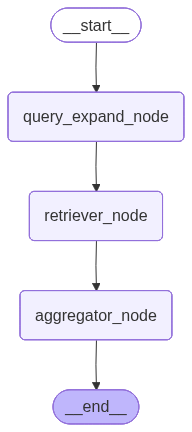

In [27]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
query = "Can I get a Tablet for my kid, a watch for me and a laptop for my wife?"
initial_state = {
    "initial_query": query
}

In [29]:
result = graph.invoke(initial_state)

In [31]:
result

{'expanded_query': ['Search for Tablet options for the specified user or family member',
  'Search for watch options for the specified user or family member',
  'Search for laptop options for the specified user or family member'],
 'retrieved_context': [{'retrieved_context_ids': ['B09S6THZJ1',
    'B0BBM8MVW3',
    'B09QKNYJBL',
    'B003IZHG6K',
    'B07C3G57MG'],
   'retrieved_contexts': ["GrandPad Tablet for Seniors, Accessibility Enabled Tablet, 4G LTE, Bluetooth Enabled Tablet with Wireless Charger, Stylus - 1 Month Premium Service with 4G Included [] Computers ['MADE FOR SENIOR CITIZENS: The GrandPad is the ideal connectivity device for your loved ones who are aging, or have hearing & eyesight issues. A simple interface & easy-connectivity makes it the perfect choice for families looking to stay connected.', 'KEEPING FAMILIES CONNECTED: The tablet comes with a custom-designed senior friendly interface, applications, unlimited 24/7/365 customer support, free companion applications

In [32]:
print(result.get("answer", []))

- Query: Search for Tablet options for the specified user or family member
  - Best option: GrandPad Tablet for Seniors
  - Why: Designed specifically for senior citizens with accessibility features, simple interface, and easy connectivity.
  - Price/Ratings: $399.0 / 4.1

- Query: Search for watch options for the specified user or family member
  - Best option: Kingstar Smart Watch
  - Why: Offers comprehensive health tracking including 24H heart rate and sleep monitoring, suitable for both men and women.
  - Price/Ratings: $96.55 / 4.1

- Query: Search for laptop options for the specified user or family member
  - Best option: ASUS Premium High Performance 14" Full HD Laptop
  - Why: Provides a good balance of performance with Intel Celeron processor, 4GB RAM, and Full HD display.
  - Price/Ratings: $389.88 / 3.2


### Query Expansion/Rewriting Node (Parallel Execution)

In [33]:
class QueryExpandResponse(BaseModel):
    expanded_query: List[str] = Field(description="List of expanded search statements derived from the initial query")

In [34]:
@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expand_node(state: State) -> dict:
    import re

    prompt_template = f"""You are an expert query expansion assistant for shopping search.
    Break the user's request into multiple non-overlapping search statements.

    Rules:
    - Identify every product mentioned in the query.
    - If multiple products are mentioned, create separate statements for each product.
    - Include family-member intent when present, such as "for me", "for my kid", or "for my family".
    - Expand the query into statements that can help retrieve product information, such as category, features, use case, budget, and brand.
    - Keep the statements specific, product-focused, and non-redundant.
    - Preserve the exact product names when they are explicitly provided.
    - Do not replace the mentioned products with unrelated products.
    - Return only the list of statements.

    Explicit products mentioned in the query:
    {{explicit_products}}

    <Question>
    {{query}}
    </Question>
    """

    def _extract_products(text: str) -> list[str]:
        quoted = re.findall(r'"([^"]+)"', text)
        phrase_matches = re.findall(r"\b(?:a|an)\s+([A-Za-z][A-Za-z0-9\- ]{1,40}?)(?=\s+(?:for|,|and|$))", text, flags=re.IGNORECASE)
        candidates = quoted + phrase_matches

        cleaned = []
        for item in candidates:
            value = re.sub(r"\s+", " ", item).strip(" .,")
            if value and len(value) > 1:
                cleaned.append(value)

        seen = set()
        ordered = []
        for item in cleaned:
            key = item.lower()
            if key not in seen:
                seen.add(key)
                ordered.append(item)
        return ordered

    template = Template(prompt_template)
    query_text = state.initial_query
    explicit_products = _extract_products(query_text)
    prompt = template.render(
        query=query_text,
        explicit_products=", ".join(explicit_products) if explicit_products else "None",
    )

    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.1,
    )

    if isinstance(response, (tuple, list)):
        response = response[0]

    if hasattr(response, "model_dump"):
        response_data = response.model_dump()
    elif hasattr(response, "dict"):
        response_data = response.dict()
    else:
        response_data = dict(response)

    statements = response_data.get("statements") or response_data.get("queries") or response_data.get("expanded_query") or []

    if explicit_products:
        filtered_statements = [
            statement for statement in statements
            if any(product.lower() in statement.lower() for product in explicit_products)
        ]
        if filtered_statements:
            return {"expanded_query": filtered_statements}

        return {
            "expanded_query": [
                f"Search for {product} options for the specified user or family member"
                for product in explicit_products
            ]
        }

    return {"expanded_query": statements}

In [35]:
def query_expand_conditional_edges(state):
    state_data = state.model_dump() if hasattr(state, "model_dump") else state
    expanded_query = state_data.get("expanded_query", []) if isinstance(state_data, dict) else []

    send_messages = []
    for query_text in expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {"k": 10, "query_text": query_text}
            )
        )

    return send_messages


In [36]:
@traceable(
        name="get_embedding",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    # Safely extract usage metadata whether response is an object or dict
    usage_obj = getattr(response, "usage", None)
    if usage_obj is None and isinstance(response, dict):
        usage_obj = response.get("usage")

    if current_run and usage_obj:
        try:
            input_tokens = getattr(usage_obj, "prompt_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("prompt_tokens")
            total_tokens = getattr(usage_obj, "total_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("total_tokens")
            current_run.add_metadata({
                "usage_metadata": {
                    "input_tokens": input_tokens,
                    "total_tokens": total_tokens,
                    "embedding_model": model,
                }
            })
        except Exception:
            # Fallback: ignore metadata errors to avoid breaking embedding
            logger = __import__("logging").getLogger(__name__)
            logger.debug("Failed to add embedding usage metadata to run")
    return response.data[0].embedding

@traceable(
        name="get_embeddings_batch",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embeddings_batch(text_list, model= "text-embedding-3-small", batch_size=100):
    if(len(text_list) <= batch_size):
        response = openai.embeddings.create(input=text_list, model=model)
        return [embedding.embedding for embedding in response.data]
    all_embeddings = []
    counter = 1
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        response = openai.embeddings.create(input=batch, model=model)
        all_embeddings.extend([embedding.embedding for embedding in response.data])
        print(f"Processed batch {counter} / {len(text_list) // batch_size + 1}")
        counter += 1
    return all_embeddings

@traceable(
        name="retrieve_data",
        tags=["retrieval", "qdrant"],
        run_type="retriever"
)
def retrieve_data(query, qdrant_client, top_k=5):
    query_embedding = get_embedding(query)
    search_result = qdrant_client.query_points(
        collection_name="Amazon_Electronics_Products",
        prefetch = [
            Prefetch(
            query = query_embedding,
            using= "text-embedding-3-small",
            limit = 20
           ),
           Prefetch(
            query = Document(text=query, model="qdrant/bm25"),
            using= "bm25",
            limit = 20
           )
        ],
        query=FusionQuery(fusion=models.Fusion.RRF),
        limit=top_k
    )

    retrieved_context_ids = []
    retrieved_contexts = []
    similarity_scores = []
    retrieved_context_ratings = []
    retrieved_context_prices = []
    retrieved_context_images = []
    retrieved_context_rating_numbers = []

    for result in search_result.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_contexts.append(result.payload['processed_description'])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload['average_rating'])
        retrieved_context_prices.append(result.payload['price'])
        retrieved_context_images.append(result.payload['image_url'])
        retrieved_context_rating_numbers.append(result.payload['rating_number'])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_contexts": retrieved_contexts,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings,
        "retrieved_context_prices": retrieved_context_prices,
        "retrieved_context_images": retrieved_context_images,
        "retrieved_context_rating_numbers": retrieved_context_rating_numbers
    }

In [37]:
@traceable(
    name="retrieve_node",
    run_type="retriever",
    tags=["retrieval", "qdrant"]
)
def retriever_node(state) -> dict:
    state_data = state.model_dump() if hasattr(state, "model_dump") else state
    query_text = None
    top_k = 5

    if isinstance(state_data, dict):
        query_text = state_data.get("query_text")
        top_k = state_data.get("k", top_k)

    if query_text:
        result = retrieve_data(query_text, qdrant_client=qdrant_client, top_k=top_k)
        result["focus_product"] = query_text
        result["query_used"] = query_text
        return {
            "retrieved_context": [result]
        }

    queries = state_data.get("expanded_query", []) if isinstance(state_data, dict) else []
    if not queries:
        queries = [state_data.get("initial_query", "")] if isinstance(state_data, dict) else [""]

    retrieved_context = []
    for query_item in queries:
        if not query_item:
            continue
        result = retrieve_data(query_item, qdrant_client=qdrant_client, top_k=top_k)
        result["focus_product"] = query_item
        result["query_used"] = query_item
        retrieved_context.append(result)

    return {
        "retrieved_context": retrieved_context
    }


@traceable(
    name="retriever_node_parallel",
    run_type="retriever",
    tags=["retrieval", "qdrant"]
)
def retriever_node_parallel(state: State, k: int = 5, query_text: str = None) -> dict:
    """Retriever node that can be invoked per-query in parallel via Send payloads.
    If `query_text` is provided in the payload, use it; otherwise fall back to `state.initial_query`.
    """
    q = query_text or state.initial_query
    result = retrieve_data(q, qdrant_client=qdrant_client, top_k=k)
    result["focus_product"] = q
    result["query_used"] = q
    return {"retrieved_context": [result]}


In [38]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question based on the retrieved contexts")

In [39]:
@traceable(
    name="aggregator_node",
    run_type="llm",
    tags=["aggregation", "openai"],
    metadata={"model": "gpt-4.1-mini", "ls-provider": "openai"}
)
def aggregator_node(state: State) -> dict:
    context_blocks = []
    for item in state.retrieved_context:
        if not isinstance(item, dict):
            continue

        snippets = item.get("retrieved_contexts", [])
        prices = item.get("retrieved_context_prices", [])
        ratings = item.get("retrieved_context_ratings", [])

        compact_items = []
        for idx, snippet in enumerate(snippets[:3]):
            compact_items.append({
                "snippet": str(snippet)[:450],
                "price": prices[idx] if idx < len(prices) else None,
                "rating": ratings[idx] if idx < len(ratings) else None,
            })

        context_blocks.append({
            "focus_product": item.get("focus_product"),
            "query_used": item.get("query_used"),
            "matches": compact_items,
        })

    preprocessed_context = json.dumps(context_blocks, ensure_ascii=True, indent=2)

    prompt_template = """You are an expert shopping assistant.

Use only the provided evidence and produce concise recommendations for each query in expanded_query.

expanded_query:
{{expanded_query}}

Evidence:
{{preprocessed_context}}

Return one section per query using this format:
- Query: <query>
  - Best option: <short title>
  - Why: <short reason>
  - Price/Ratings: <if available>
"""

    template = Template(prompt_template)
    prompt = template.render(
        expanded_query=json.dumps(state.expanded_query, ensure_ascii=True),
        preprocessed_context=preprocessed_context,
    )

    try:
        client = instructor.from_openai(OpenAI())
        response = client.chat.completions.create_with_completion(
            model="gpt-4.1-mini",
            response_model=AggregatorResponse,
            messages=[{"role": "system", "content": prompt}],
            temperature=0.1,
            timeout=20,
        )

        if isinstance(response, (tuple, list)):
            response = response[0]

        return {"answer": response.answer}
    except Exception:
        fallback_lines = []
        for block in context_blocks:
            query_label = block.get("query_used") or "query"
            first = block.get("matches", [])
            if first:
                top = first[0]
                fallback_lines.append(
                    f"- Query: {query_label}\n"
                    f"  - Best option: {top.get('snippet', 'N/A')[:100]}\n"
                    f"  - Why: Based on retrieved context.\n"
                    f"  - Price/Ratings: price={top.get('price')}, rating={top.get('rating')}"
                )
            else:
                fallback_lines.append(
                    f"- Query: {query_label}\n"
                    f"  - Best option: Insufficient evidence\n"
                    f"  - Why: No context returned.\n"
                    f"  - Price/Ratings: N/A"
                )

        return {"answer": "\n\n".join(fallback_lines)}

In [40]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()


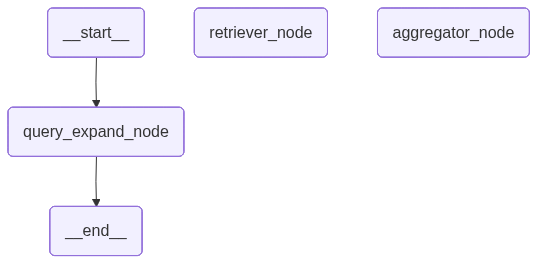

In [41]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
query = "Can I get a Tablet for my kid, a watch for me and a laptop for my wife?"
initial_state = {
    "initial_query": query
}

In [43]:
result = graph.invoke(initial_state)

In [82]:
result

{'expanded_query': ['Search for Tablet options for the specified user or family member',
  'Search for watch options for the specified user or family member',
  'Search for laptop options for the specified user or family member'],
 'retrieved_context': [{'retrieved_context_ids': ['B09S6THZJ1',
    'B0BBM8MVW3',
    'B09QKNYJBL',
    'B003IZHG6K',
    'B07C3G57MG',
    'B073XD76GT',
    'B07F4P3JH7',
    'B00JE5EP0S',
    'B0B852M28H',
    'B098ZFMY25'],
   'retrieved_contexts': ["GrandPad Tablet for Seniors, Accessibility Enabled Tablet, 4G LTE, Bluetooth Enabled Tablet with Wireless Charger, Stylus - 1 Month Premium Service with 4G Included [] Computers ['MADE FOR SENIOR CITIZENS: The GrandPad is the ideal connectivity device for your loved ones who are aging, or have hearing & eyesight issues. A simple interface & easy-connectivity makes it the perfect choice for families looking to stay connected.', 'KEEPING FAMILIES CONNECTED: The tablet comes with a custom-designed senior friendly

In [49]:
print(result.get("answer", []))

- Query: Search for Tablet options for the specified user or family member
  - Best option: GrandPad Tablet for Seniors
  - Why: Designed specifically for senior citizens with accessibility features, simple interface, and easy connectivity.
  - Price/Ratings: $399.0 / 4.1

- Query: Search for watch options for the specified user or family member
  - Best option: Kingstar Smart Watch
  - Why: Offers comprehensive health tracking features including 24H heart rate and sleep monitoring, suitable for both men and women.
  - Price/Ratings: $96.55 / 4.1

- Query: Search for laptop options for the specified user or family member
  - Best option: ASUS Premium High Performance 14" Full HD Laptop
  - Why: Provides a good balance of performance with Intel Celeron processor, 4GB RAM, and Full HD display.
  - Price/Ratings: $389.88 / 3.2


### User Intent Router Node

In [50]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool = Field(description="Whether the question is relevant to shopping search")
    answer: str = Field(description="Answer to the question if it is relevant, otherwise can be empty or a polite decline")

In [51]:
@traceable(
    name="intent_router_node",
    run_type="llm",
    tags=["routing", "openai"],
    metadata={"model": "gpt-4.1-mini", "ls-provider": "openai"}
)
def intent_router_node(state: State) -> dict:
    prompt_template = """You are an intent router for a shopping search assistant.
Determine if the user's question is relevant to shopping search and can be answered based on product information.
If the question is relevant, provide a concise answer. If not, politely decline to answer.
Question:
{{query}}
"""

    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)

    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=IntentRouterResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.1,
    )

    if isinstance(response, (tuple, list)):
        response = response[0]

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }


In [66]:
def intent_router_route(state):
   state_data = state.model_dump() if hasattr(state, "model_dump") else state
   question_relevant = False

   if isinstance(state_data, dict):
      question_relevant = bool(state_data.get("question_relevant", False))
   else:
      question_relevant = bool(getattr(state, "question_relevant", False))

   if question_relevant:
      return "query_expand_node"
   else:
        return "end"


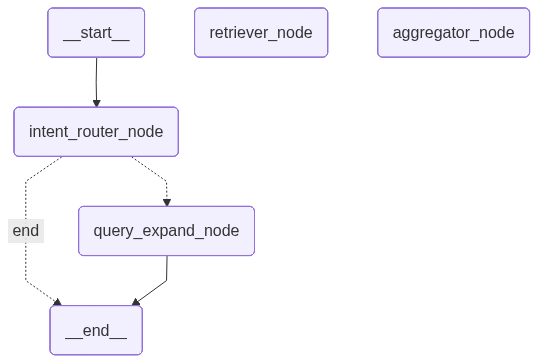

In [ ]:
# workflow = StateGraph(State)
# workflow.add_node("query_expand_node", query_expand_node)
# workflow.add_node("retriever_node", retriever_node)
# workflow.add_node("aggregator_node", aggregator_node)
# workflow.add_node("intent_router_node", intent_router_node)

# workflow.add_edge(START, "intent_router_node")
# workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)
# workflow.add_conditional_edges("intent_router_node", intent_router_conditional_edges, {
#     "query_expand_node" : "query_expand_node",
#     "end": END
# })

# workflow.add_edge("retriever_node", "aggregator_node")
# workflow.add_edge("aggregator_node", END)    

# graph = workflow.compile()
# display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
workflow = StateGraph(State)
workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_edge("intent_router_node", "query_expand_node")
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()


In [ ]:
graph = workflow.compile()

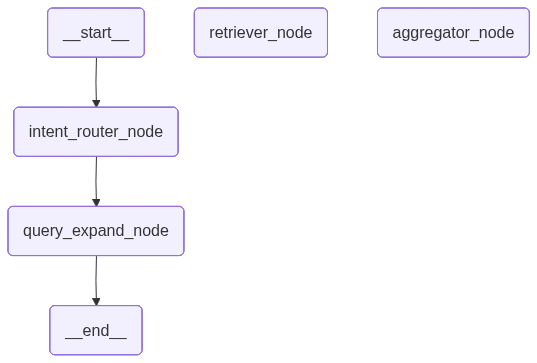

In [86]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [87]:
query = "Can I get a Tablet for my kid, a watch for me, a laptop for my wife and a waterproof speaker for our party next week?"
initial_state = {
    "initial_query": query
}

In [92]:
result = graph.invoke(initial_state)

In [93]:
print(result.get("answer", []))

- Query: Search for Tablet options for the specified user or family member
  - Best option: GrandPad Tablet for Seniors
  - Why: Designed specifically for senior citizens with accessibility features and easy connectivity.
  - Price/Ratings: $399.0 / 4.1

- Query: Search for watch options for the specified user or family member
  - Best option: Kingstar Smart Watch
  - Why: Waterproof with fitness tracking features including heart rate and sleep monitoring.
  - Price/Ratings: $96.55 / 4.1

- Query: Search for laptop options for the specified user or family member
  - Best option: GrandPad Tablet for Seniors (also suitable as a laptop alternative)
  - Why: Accessibility enabled and easy to use for seniors.
  - Price/Ratings: $399.0 / 4.1

- Query: Search for waterproof speaker options for the specified user or family member
  - Best option: MEGUO Bluetooth Speaker with Bass+
  - Why: IPX7 waterproof rating, 24-hour playtime, and enhanced bass.
  - Price/Ratings: $96.55 / 4.2


In [94]:
print(result)

{'expanded_query': ['Search for Tablet options for the specified user or family member', 'Search for watch options for the specified user or family member', 'Search for laptop options for the specified user or family member', 'Search for waterproof speaker options for the specified user or family member'], 'retrieved_context': [{'retrieved_context_ids': ['B09S6THZJ1', 'B0BBM8MVW3', 'B09QKNYJBL', 'B003IZHG6K', 'B07C3G57MG', 'B073XD76GT', 'B07F4P3JH7', 'B00JE5EP0S', 'B0B852M28H', 'B00JQN5ZAM'], 'retrieved_contexts': ["GrandPad Tablet for Seniors, Accessibility Enabled Tablet, 4G LTE, Bluetooth Enabled Tablet with Wireless Charger, Stylus - 1 Month Premium Service with 4G Included [] Computers ['MADE FOR SENIOR CITIZENS: The GrandPad is the ideal connectivity device for your loved ones who are aging, or have hearing & eyesight issues. A simple interface & easy-connectivity makes it the perfect choice for families looking to stay connected.', 'KEEPING FAMILIES CONNECTED: The tablet comes w

In [95]:
print(len(result.get("retrieved_context", [])))


4
